### <center> <span style="color:pink;"> A Trilha da Acadêmica </span> </center>

# <center> <span style="color:pink;"> **Redes Neurais Recorrentes**  </span> </center>

<center> Autor: Luiza Davoli </center>

## <span style="color:pink;"> Sumário </span> 

1. Introdução
    - O que é e como funciona uma RNN
    - Que tipo de problema uma RNN pode resolver?
2. Tipos de RNN
3. Tratamento de dados
4. Backpropagation
    - Problema do Gradiente
5. RNN em Pytorch/Lightning
6. Conclusão
7. Referências

## <span style="color:pink;"> Introdução </span> 

### <span style="color:pink;"> O que é e como funciona uma RNN </span> 

As **Redes Neurais Recorrentes** (RNN) são projetadas para processar e prever dados sequenciais, como textos ou séries temporais. Seu diferencial é a capacidade de armazenar uma "memória" das entradas anteriores por meio de loops de feedback. [1]

De forma simplificada, a estrutura de uma RNN pode ser exemplificada com o esquema a seguir: 

<img src="rnn_esquema_geral.png" alt="esquema geral de uma RNN" height="300">

Fonte: https://www.datacamp.com/pt/tutorial/tutorial-for-recurrent-neural-network

A camada intermediária <span style="color:springgreen;">**A**</span> é responsável por analisar os dados de entrada <span style="color:lightskyblue;">**X**</span> e gerar um valor <span style="color:hotpink;"> **H** </span>.

Resumidamente, um loop (representado na imagem por uma seta que sai de <span style="color:springgreen;">**A**</span> e entra em <span style="color:springgreen;">**A**</span>) permite que parâmetros e informações sejam passados de uma etapa da rede para a outra [2].

Ao "desenrolar" o esquema acima, podemos entender um pouco melhor como a RNN funciona:

<img src="rnn_desenrolada.png" alt="RNN mais detalhada" height="200">

Fonte: https://www.datacamp.com/pt/tutorial/tutorial-for-recurrent-neural-network

Uma RNN pode ser entendida como uma mesma rede repetida várias vezes, sendo que dados são passados ao sucessor a cada repetição [2]. 

Caso essa explicação ainda esteja confusa, tomemos um exemplo numérico. Supondo uma lista de dados de entrada [1, 2, 3, 4] e a rede neural com uma função extremamente simples: prever a soma dos dados de entrada. Nesse caso, temos que:
- $X_0$ = 1
- $X_1$ = 2
- $X_2$ = 3
- $X_3$ = 4

No primeiro ciclo, a camada intermediária recebe o valor 1 e retorna o resultado 1, como estamos acostumados. Em uma rede neural mais simples, esse padrão se repetiria para todos os dados de entrada, fazendo com que cada saída representasse exatamente o valor que entrou.

Porém, em uma RNN, isso não acontece. No segundo ciclo, vemos que existem duas setas entrando na camada intermediária <span style="color:springgreen;">**A**</span>: uma contendo o valor de entrada 2 e a outra o resultado do último ciclo (1). Esses dois dados serão somados (função definida acima), retornando o valor de saída 3.

Da mesma forma, no terceiro ciclo, teremos o valor de entrada 3 e o resultado do ciclo anterior (3), resultando em um valor de saída 6. O mesmo ocorre para o quarto ciclo, que receberá os valores 4 e 6, prevendo um valor 10.

### <span style="color:pink;"> Que tipo de problema uma RNN pode resolver? </span> 

Como citado anteriormente, as RNNs são especialistas em problemas que envolvem dados sequenciais, onde a ordem das informações é fundamental para o entendimento do todo. Em seu site, Matheus Facure [3] utiliza o seguinte exemplo:

> Tente ler a seguinte frase:
>
> `Miséria nossa de legado o criatura nenhuma a transmiti não, filhos tive não.`
>
> Ela não faz muito sentido, mas se a colocarmos na ordem certa você facilmente reconhecerá o fim de Memórias Póstumas de Brás Cubas:
>
> `Não tive filhos, não transmiti a nenhuma criatura o legado de nossa miséria.`

Esse exemplo é perfeito para mostrar como, até para o nosso cérebro, é difícil entender um contexto quando temos apenas palavras em ordem aleatória. Mesmo que as palavras sejam as mesmas, quando mudamos a ordem em que elas estão dispostas, passamos uma mensagem totalmente diferente. Dados que só podem ser entendidos quando dispostos de maneira correta são chamados de dados sequenciais. É com esse tipo de dado que as RNNs trabalham.

Dentre as aplicações práticas desse modelo de rede neural, podemos citar:
- Processamento de Linguagem Natural (PLN): São usadas para **tradução automática** (como de português para inglês), **análise de sentimentos** em textos, **reconhecimento de voz** e até para **gerar textos novos**, como poemas ou códigos de programação. [4]
- Séries Temporais e Finanças: Excelente para **prever tendências no mercado** de ações, taxas de juros, **consumo de energia** ou **mudanças climáticas**. [5]
- Visão Computacional e Vídeo: Permitem **descrever o conteúdo de uma imagem** (legendas automáticas) ou **prever qual será a próxima ação de uma pessoa** em um vídeo analisando os frames anteriores. [6]
- Biologia e Saúde: São aplicadas no **sequenciamento de DNA** e **análise de genomas**. [5]

## <span style="color:pink;"> Tipos de RNN </span> 

<img src="Tipos_RNN.png" alt="tipos de RNN" height="400">

Fonte: adaptado de https://www.youtube.com/watch?v=GvezxUdLrEk

As RNNs podem ser classificadas de acordo com a a quantidade de dados de entrada e de saída ou pela sua arquitetura para lidar com a memória.


**1. Classificação por Estrutura de Entrada e Saída** [7]

**Um para um** (One to One): 

É o modelo básico de uma rede neural tradicional, que processa uma única entrada para gerar uma única saída.

- Exemplo: Prever se um aluno será aprovado na disciplina (classificação binária)

    - Entrada: [7] (Nota do aluno)

    - Saída: Aprovado


**Muitos para um** (Many-to-One): 

Recebe uma sequência de entradas para produzir um resultado único. 

- Exemplo: Análise se sentimento é positivo ou negativo

    - Entradas: Essa notícia me encheu de esperança para o futuro

    - Saída: Positivo

**Um para muitos** (One to Many): 

Recebe uma entrada fixa (como uma imagem) e gera uma sequência de dados como saída. 

- Exemplo: Descrição automática de imagens (image captioning)

    - Entrada: 
    
    <img src="imagem_exemplo.png" alt="imagem de cachorro" width="300" height="200">

    - Saídas: Cachorro caramelo muito fofo deitado na cama :)

**Muitos para muitos** (Many to Many): 

Envolve sequências em ambas as pontas. Pode ser assíncrona, como na tradução automática, onde a rede lê uma frase inteira antes de começar a traduzir. Ou pode ser sincronizada, onde cada entrada gera uma saída imediata no mesmo passo de tempo, como na rotulagem de cada quadro de um vídeo.

- Exemplo: Tradução de um texto

    - Entradas: “Small steps still move you forward.”

    - Saídas: “Pequenos passos ainda te levam para frente.”


**2. Mecanismos de Memória**

**RNN Tradicional**: 

Possui uma estrutura simples com uma única camada de ativação, mas tem dificuldade em conectar informações separadas por grandes intervalos. [9]

<img src="RNN_simples.png" alt="esquema de uma RNN tradicional" height="200">

Fonte: https://colah.github.io/posts/2015-08-Understanding-LSTMs/

**Long Short-Term Memory (LSTM)**:

Projetada especialmente para aprender dependências de longo prazo. As LSTMs utilizam uma estrutura complexa de quatro camadas que interagem entre si, incluindo o "estado de célula" (que atua como uma esteira transportadora de informações) e portões (gates) de esquecimento, entrada e saída para gerenciar o que deve ser mantido ou descartado da memória.

<img src="LSTM.png" alt="LSTM esquema" height="200">

<img src="LSTM_components.png" alt="componentes de uma LSTM" height="100">

Fonte de ambas as imagens: https://colah.github.io/posts/2015-08-Understanding-LSTMs/

Em seu site [2], Christopher Olah cita diversas variações de métodos usados em RNNs, como Gated Recurrent Unit (GRU), Depth Gated RNNs, Clockwork RNNs, Grid LSTMs. Não irei me aprofundar nesses outros tipos, já que são mais específicos para algumas aplicações e não são tão famosos.

## <span style="color:pink;"> Tratamento de dados </span> 

Para que uma RNN consiga processar informações, os dados devem ser transformados de sua forma bruta para uma estrutura matemática que a rede consiga interpretar.

Assim como em outros modelos de aprendizado de máquinas, as RNNs não interpretam dados categóricos, sendo necessário realizar uma conversão numérica (encoding) [4]. O tipo de encoding utilizado dependerá da estrutura e tipo dos dados.

Para dados numéricos com grande variação, é crucial aplicar técnicas de normalização. O uso de ferramentas de normalização ajuda a colocar todos os dados em uma mesma escala. Isso evita que valores muito altos dominem o cálculo dos pesos e causem instabilidade no treinamento, como ocorre no problema do gradiente explosivo, que será abordado a seguir.

**Redimensionamento do Formato (Reshaping)**

Algumas bibliotecas, como Pytorch, exigem que os dados de entrada estejam em um formato de tensor específico, geralmente tridimensional, contendo número de amostras (quantidade de sequências), intervalo de tempo e número de features [1].

Essa estruturação permite que a rede aplique os mesmos pesos a cada elemento da sequência, criando a constância necessária para a "memória" da rede.

**Estruturação em Janelas Temporais (Sliding Windows)**

Como esse modelo é muito dependente da ordem dos dados, é preciso organizar as entradas em sequências menores, que permitem que a rede identifique padrões sequenciais locais com maior facilidade. Para isso, são definidos "passos de tempo" (time steps), que limitam o número de dados inclusos nessas pequenas "caixas" ou "janelas" [10].

## <span style="color:pink;"> Backpropagation </span> 

O backpropagation em uma RNN é conhecido como **Backpropagation Through Time** (BPTT) ou Retropropagação ao Longo do Tempo. Como as RNNs possuem loops, o algoritmo funciona tratando a rede como se ela fosse "desenrolada" no tempo, assemelhando-se a uma rede neural muito profunda com várias camadas, onde cada camada representa um passo de tempo na sequência. [6]

O processo segue estas etapas:
- Propagação para frente (*Forward Pass*): A rede processa a sequência completa, calculando os estados ocultos e gerando previsões para cada instante de tempo [4]. 

- Cálculo do erro acumulado: O erro (perda) é calculado em cada passo de tempo individualmente. A perda total da rede é a soma de todos esses erros ao longo da sequência [1].

- Retropropagação (*Backward Pass* ou *Backpropagation*): O algoritmo percorre a rede de trás para frente, do último passo de tempo até o primeiro. Nesse processo, ele calcula como cada peso contribuiu para o erro total em cada momento da sequência de acordo com o valor do gradiente local [8]. 

- Atualização de pesos compartilhados: Diferente de uma rede comum, a RNN utiliza os mesmos pesos em todos os passos de tempo. Por isso, o BPTT acumula os ajustes necessários de todos os instantes para atualizar os pesos ao final do processo [1].

Um desafio desse método é que, ao multiplicar gradientes repetidamente através de muitos passos de tempo, eles podem se tornar minúsculos (gradiente de desaparecimento) ou excessivamente grandes (gradiente explosivo), o que impede a rede de aprender dependências de longo prazo.


### <span style="color:pink;"> Problema do Gradiente </span> 

Como citado anteriormente, durante o treinamento via Backpropagation Through Time (BPTT), devido à repetição de multiplicações dos gradientes ao longo de muitos passos de tempo, é possível que ocorram problemas com o cálculo do gradiente [4].

**Gradiente que Desaparece (*Vanishing*)**

Ao multiplicar valores muito pequenos repetidamente, o gradiente torna-se insignificante. Isso faz com que a rede "esqueça" informações distantes e pare de aprender dependências de longo prazo [2].

**Gradiente que Explode (*Exploding*)** 

Ocorre quando os gradientes se acumulam e tornam-se excessivamente altos, resultando em pesos instáveis e um modelo que demora excessivamente para convergir ou até mesmo não converge [1].

## <span style="color:pink;"> RNN em Pytorch/Lightning </span> 

O exemplo de rede neural abaixo foi baseado no vídeo disponível na referência [9]. 

Nessa primeira etapa, será realizado apenas o tratamento e separação dos dados, sem nenhuma função específica da RNN (com excessão da definição da janela).

In [61]:
# Importando as bibliotecas
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pytorch_lightning as pl
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [62]:
# Carregar e preparar os dados
df = pd.read_csv("PETR4.SA2.csv")
df = df.dropna()
# Dados selecionados como target: valor de fechamento das ações
prices = df['Close'].values.astype(np.float32)

In [63]:
# Hiperparâmetros
days_time_step = 15      # tamanho da janela de entrada (em dias)

# Divisão em treino, teste e validação
train_size = 0.85
val_size = 0.10
test_size = 1.0 - train_size - val_size  
n = len(prices)
train_end = int(n * train_size)
val_end = train_end + int(n * val_size)


train_data = prices[:train_end]
val_data = prices[train_end - days_time_step : val_end]
test_data = prices[val_end - days_time_step : ]


# Normalização
scaler = MinMaxScaler(feature_range=(0, 1))
train_norm = scaler.fit_transform(train_data.reshape(-1, 1))
val_norm = scaler.transform(val_data.reshape(-1, 1))
test_norm = scaler.transform(test_data.reshape(-1, 1))

# Criação das janelas deslizantes
# Treino
X_train, y_train = [], []
for i in range(days_time_step, len(train_norm)):
    X_train.append(train_norm[i - days_time_step : i, 0]) 
    y_train.append(train_norm[i, 0])

# Validação
X_val, y_val = [], []
for i in range(days_time_step, len(val_norm)):
    X_val.append(val_norm[i - days_time_step : i, 0])
    y_val.append(val_norm[i, 0])

# Teste
X_test, y_test = [], []
for i in range(days_time_step, len(test_norm)):
    X_test.append(test_norm[i - days_time_step : i, 0])
    y_test.append(test_norm[i, 0])


X_train = np.array(X_train).reshape(-1, days_time_step, 1)
y_train = np.array(y_train).reshape(-1, 1)
X_val   = np.array(X_val).reshape(-1, days_time_step, 1)
y_val   = np.array(y_val).reshape(-1, 1)
X_test  = np.array(X_test).reshape(-1, days_time_step, 1)
y_test  = np.array(y_test).reshape(-1, 1)


# Converter para tensores e criar dataloaders
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
y_val_t   = torch.tensor(y_val, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

A seguir, será definida a função da RNN em si.

Após alguns testes, percebi que os hiperparâmetros utilizados são razoavelmente bons, permitindo a convergência do modelo. Portanto, não há uma justificativa matemática para essas escolhas, mas sim uma observação experimental.

In [64]:
# Definindo a RNN
class RNN(pl.LightningModule):
    def __init__(self, input_size=1, hidden_size=200, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        out, _ = self.rnn(x)      
        out = out[:, -1, :]           # pega apenas o último instante da sequência
        return self.fc(out)       

    def training_step(self, batch):
        x, y = batch
        pred = self(x)
        loss = self.loss_fn(pred, y)
        self.log('train_loss', loss, prog_bar=False, on_step=False, on_epoch=True)
        # on_step = False: não calcula a perda a cada passo de tempo, mas sim a cada época
        return loss

    def validation_step(self, batch):
        x, y = batch
        pred = self(x)
        loss = self.loss_fn(pred, y)
        self.log('val_loss', loss, prog_bar=False, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=0.001)

Assim como na definição do modelo, os parâmetros definidos a seguir são puramente experimentais. Algumas escolhas, como o número de épocas, foram feitas para acelerar o processo, buscando não diminuir muito a acurácia do modelo.

In [65]:
# Instanciando o modelo
model = RNN(input_size=1, hidden_size=200, output_size=1)

# 4. Treinamento com o Lightning
trainer = pl.Trainer(
    max_epochs=50,
    log_every_n_steps=3,
    enable_progress_bar=False
)

trainer.fit(model, train_loader, val_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ rnn     │ RNN     │ 40.6 K │ train │     0 │
│ 1 │ fc      │ Linear  │    201 │ train │     0 │
│ 2 │ loss_fn │ MSELoss │      0 │ train │     0 │
└───┴─────────┴─────────┴────────┴───────┴───────┘

Trainable params: 40.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 40.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\luiza25030\AppData\Roaming\Python\Python312\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\luiza25030\AppData\Roaming\Python\Python312\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
C:\Users\luiza25030\AppData\Roaming\Python\Python312\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=50` reached.


Por fim, para visualizar os resultados, foram adicionados alguns gráficos e métricas de desempenho.

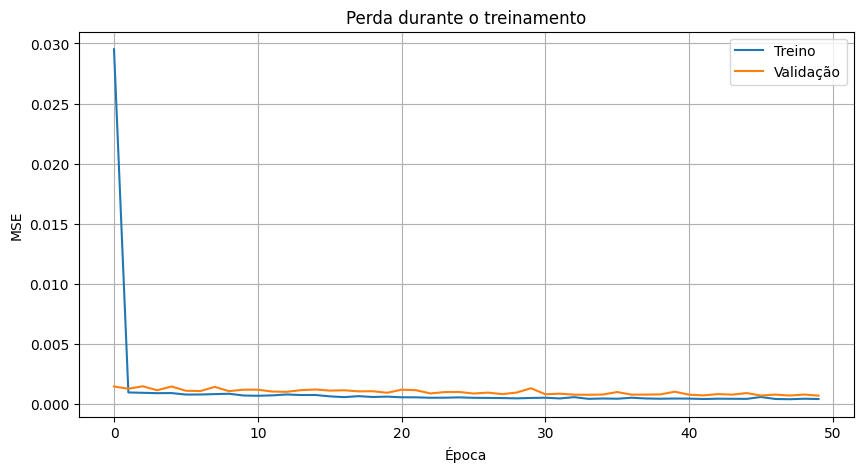

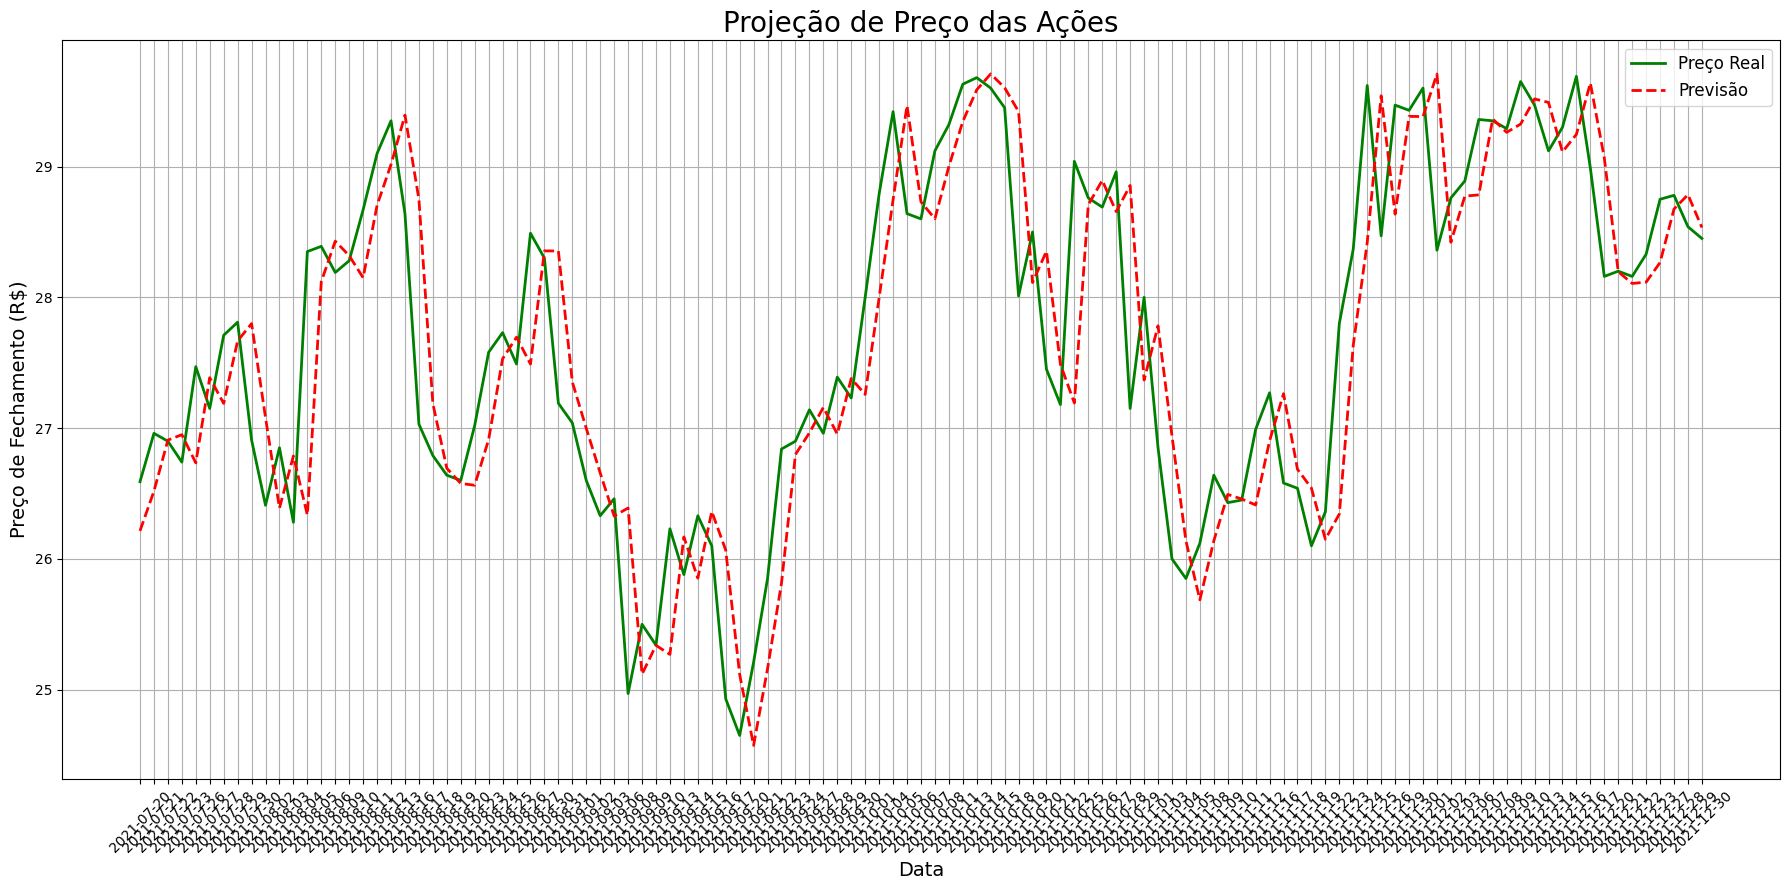

MSE: 0.4305
RMSE: 0.6561


In [66]:
# Gráficos para visualização
log_dir = trainer.logger.log_dir
metrics_file = os.path.join(log_dir, 'metrics.csv')
if os.path.exists(metrics_file):
    metrics = pd.read_csv(metrics_file)
    plt.figure(figsize=(10, 5))
    train_cols = [c for c in metrics.columns if 'train_loss' in c]
    val_cols   = [c for c in metrics.columns if 'val_loss' in c]
    if train_cols and 'epoch' in metrics.columns:
        train_df = metrics[['epoch'] + [train_cols[0]]].dropna()
        plt.plot(train_df['epoch'], train_df[train_cols[0]], label='Treino')
    if val_cols and 'epoch' in metrics.columns:
        val_df = metrics[['epoch'] + [val_cols[0]]].dropna()
        plt.plot(val_df['epoch'], val_df[val_cols[0]], label='Validação')
    plt.xlabel('Época')
    plt.ylabel('MSE')
    plt.title('Perda durante o treinamento')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Arquivo de métricas não encontrado em", log_dir)

model.eval()
with torch.no_grad():
    pred_norm = model(X_test_t).numpy()

# Transformando novamente os dados para a escala normal
pred_real = scaler.inverse_transform(pred_norm)
real_real = scaler.inverse_transform(y_test)  

test_dates = df['Date'].iloc[-len(y_test):].values
plt.figure(figsize=(18, 9))
plt.plot(test_dates, real_real, color='green', linewidth=2, label='Preço Real')
plt.plot(test_dates, pred_real, color='red', linestyle='--', linewidth=2, label='Previsão')
plt.xticks(rotation=45)
plt.xlabel('Data', fontsize=14)
plt.ylabel('Preço de Fechamento (R$)', fontsize=14)
plt.title('Projeção de Preço das Ações', fontsize=20)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

mse = mean_squared_error(real_real, pred_real)
rmse = np.sqrt(mse)
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

## <span style="color:pink;"> Conclusão </span> 

O modelo de RNN treinado com PyTorch Lightning para previsão do preço de fechamento da PETR4 apresentou os seguintes resultados no conjunto de teste:

- MSE: 0.4305
- RMSE: 0.6561

Esse valor de RMSE indica que, em média, as previsões do modelo erram R$ 0,65 em relação ao preço real. Considerando que as ações da PETR4 oscilam aproximadamente na faixa de R$ 20,00 a R$ 40,00, esse erro representa aproximadamente 1,6% a 3,3% do valor real, o que pode ser considerado um resultado razoável para uma RNN comum.

Vale destacar que esse resultado é parcialmente causado pela aleatoriedade do treinamento, ou seja, como o código não possui semente fixada, execuções diferentes podem produzir resultados ligeiramente distintos, mas provavelmente não terão grandes alterações.

É importante citar que mercados financeiros são influenciados por fatores externos (como notícias, cenário macroeconômico e geopolítica), fatores que o modelo não consegue capturar.

Possivelmente, um modelo com uma memória de longo prazo (como o LSTM) poderia melhorar as predições, já que seria possível incluir um período de tempo maior na análise dos dados.

## <span style="color:pink;"> Referências </span> 

[1] DATACAMP. *Tutorial sobre redes neurais recorrentes (RNNs)*. Disponível em: https://www.datacamp.com/pt/tutorial/tutorial-for-recurrent-neural-network. Acesso em: 15 abr. 2026.

[2] OLAH, Christopher. *Understanding LSTM Networks*. Disponível em: https://colah.github.io/posts/2015-08-Understanding-LSTMs/. Acesso em: 20 abr. 2026.

[3] FACURE, Matheus. *Redes neurais recorrentes*. Disponível em: https://matheusfacure.github.io/2017/09/12/rnn/. Acesso em: 15 abr. 2026.

[4] UNIVERSO DISCRETO. *Entenda redes neurais recorrentes (RNN) | Redes neurais e deep learning 11*. YouTube, 2022. Disponível em: https://www.youtube.com/watch?v=lrAT0oEfvIg. Acesso em: 20 abr. 2026.

[5] DATA SCIENCE ACADEMY. *Redes neurais recorrentes*. Deep Learning Book Brasil. Disponível em: https://www.deeplearningbook.com.br/redes-neurais-recorrentes/. Acesso em: 15 abr. 2026.

[6] IA EXPERT ACADEMY. *Introdução a Redes Neurais Recorrentes*. Youtube, 2018. Disponível em: https://www.youtube.com/watch?v=ZvBJxh5O3H0. Acesso em 20 abr. 2026.

[7] MASSACHUSETTS INSTITUTE OF TECHNOLOGY (MIT). *Neural networks, transformers, and attention*. YouTube. Disponível em: https://www.youtube.com/watch?v=GvezxUdLrEk. Acesso em: 20 abr. 2026.

[8] Andrej Karpathy. *The unreasonable effectiveness of recurrent neural networks*. Disponível em: https://karpathy.github.io/2015/05/21/rnn-effectiveness/. Acesso em: 20 abr. 2026.

[9] UNIVERSO DISCRETO. *Prever ações da Petrobras usando redes neurais recorrentes | Redes neurais e deep learning 12*. YouTube, 2022. Disponível em: https://www.youtube.com/watch?v=iP4323wII-I. Acesso em: 20 abr. 2026.

[10] PROFOUND ACADEMY. *Sliding Window Technique*. YouTube, 2024. Disponível em: https://www.youtube.com/watch?v=dOonV4byDEg. Acesso em: 8 maio 2026.

Material de aula disponibilizado pelo professor Daniel Roberto Cassar.